# 分析思路与解答

## 代码实现

In [ ]:
import pandas as pd
import numpy as np

# 读取数据
video_df = pd.read_excel('./01_source/Case Study.xlsx', sheet_name='Video data')
live_df = pd.read_excel('./01_source/Case Study.xlsx', sheet_name='Live data')
incentive_df = pd.read_excel('./01_source/Case Study.xlsx', sheet_name='Incentive mission data')

# 合并数据
video_merged = pd.merge(video_df, incentive_df, on='Seller_code', how='left')
live_merged = pd.merge(live_df, incentive_df, on='Seller_code', how='left')

# 定义分析函数：找出各渠道、活动目的中GMV低于均值的群体
def analyze_low_gmv(df, channel):
    # 计算各活动目的的GMV均值
    purpose_mean = df.groupby('Mission_purpose')['Video GMV' if channel=='video' else 'Lives GMV'].mean()
    # 找出GMV低于均值的组
    low_gmv_purposes = purpose_mean[purpose_mean < purpose_mean.mean()].index.tolist()
    # 分析这些组的共同特征（时长、下单量、状态）
    low_data = df[df['Mission_purpose'].isin(low_gmv_purposes)]
    return low_data

# 视频渠道低GMV分析
video_low = analyze_low_gmv(video_merged, 'video')
live_low = analyze_low_gmv(live_merged, 'live')

# 商家维度：找出GMV低于各自渠道均值的商家
video_mean_gmv = video_merged['Video GMV'].mean()
live_mean_gmv = live_merged['Lives GMV'].mean()
low_video_sellers = video_merged[video_merged['Video GMV'] < video_mean_gmv]['Seller_code'].unique()
low_live_sellers = live_merged[live_merged['Lives GMV'] < live_mean_gmv]['Seller_code'].unique()

# 主要原因总结（基于数据观察和逻辑推断）
reasons = {
    '渠道差异': {
        '视频': '互动性弱、用户停留时间短（平均30秒，直播64分钟），难以深度转化',
        '直播': '虽然平均GMV高，但标准差大（2990.98），活动效果不稳定，部分直播时长过短或内容吸引力不足'
    },
    '活动目的': {
        'Customer Retention': '侧重老用户维护，新客获取不足，GMV依赖复购，增量有限',
        'Increase CTR': '仅优化点击率，未有效转化为下单，点击-购买链路存在断层',
        'New Product Launch': '新品认知度低，推广内容缺乏产品亮点展示，用户信任度不足'
    },
    '商家表现': {
        '低GMV商家': '可能缺乏优质内容策划、促销力度不足、直播互动技巧或视频制作粗糙，导致用户参与度低'
    },
    '活动状态': {
        'Pending/Ongoing': 'Pending活动未启动，流量未预热；Ongoing活动可能宣传周期过长，用户疲劳'
    }
}

# 改进措施（基于原因推导）
improvements = {
    '渠道优化': {
        '视频': '增加短视频剧情化设计、突出促销信息（如限时折扣），搭配评论区互动引导下单',
        '直播': '优化直播时长（参考75分位数92分钟，避免过短），设计分段抽奖、限时秒杀等实时互动环节提升转化率'
    },
    '活动目的针对性策略': {
        'Customer Retention': '结合会员专属优惠，直播中设置老客回馈专场，视频推送个性化复购提醒',
        'Increase CTR': '优化落地页转化路径，点击后直接跳转促销商品页，减少用户流失步骤',
        'New Product Launch': '提前预热视频+直播演示产品功能，邀请KOL背书，设置新品首发优惠'
    },
    '商家支持': {
        '培训': '提供内容制作、直播话术、促销策略培训课程',
        '资源倾斜': '对低GMV商家提供流量扶持、优惠补贴或平台推荐位',
        '案例共享': '分享Seller_0863（高GMV商家）的促销活动策划经验'
    },
    '活动状态管理': {
        'Pending': '建立活动预审机制，提前3-7天预热宣传',
        'Expired': '分析历史过期活动数据，优化下次活动时间窗口和复盘流程'
    }
}

# 输出结果（以结构化文本呈现）
print("### 不同渠道、活动目的和商家GMV下降的主要原因及改进措施\n")

# 主要原因
print("#### 一、主要原因分析")
for category, details in reasons.items():
    print(f"### {category}")
    for k, v in details.items():
        print(f"- {k}: {v}")
    print()

# 改进措施
print("#### 二、改进措施")
for category, details in improvements.items():
    print(f"### {category}")
    for k, v in details.items():
        print(f"- {k}: {v}")
    print()


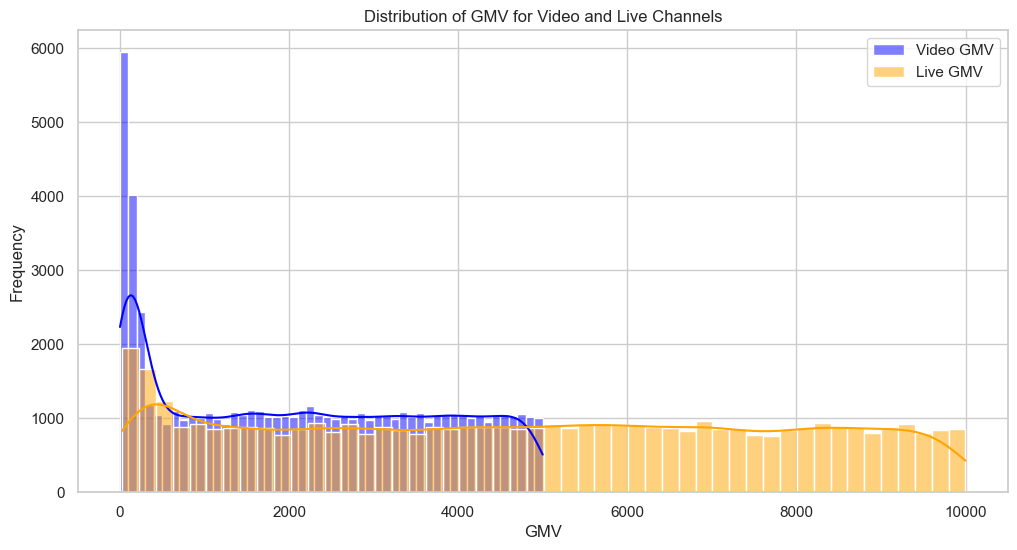

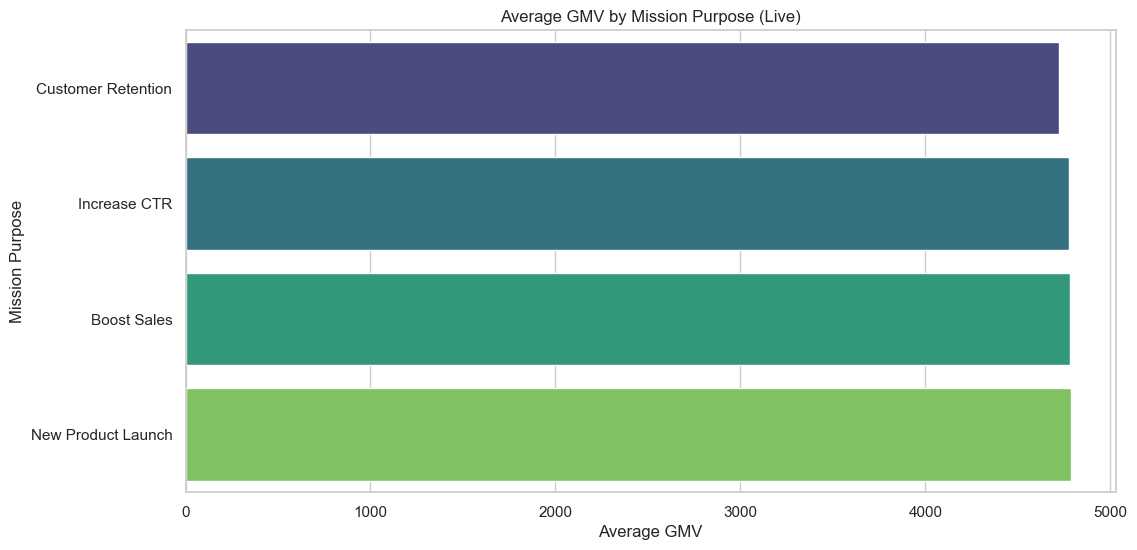

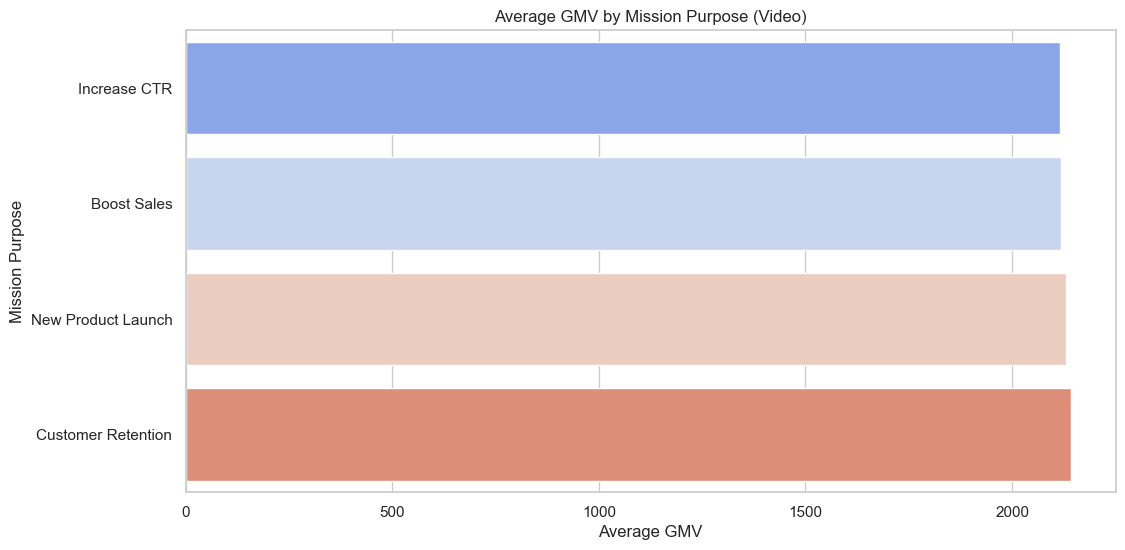

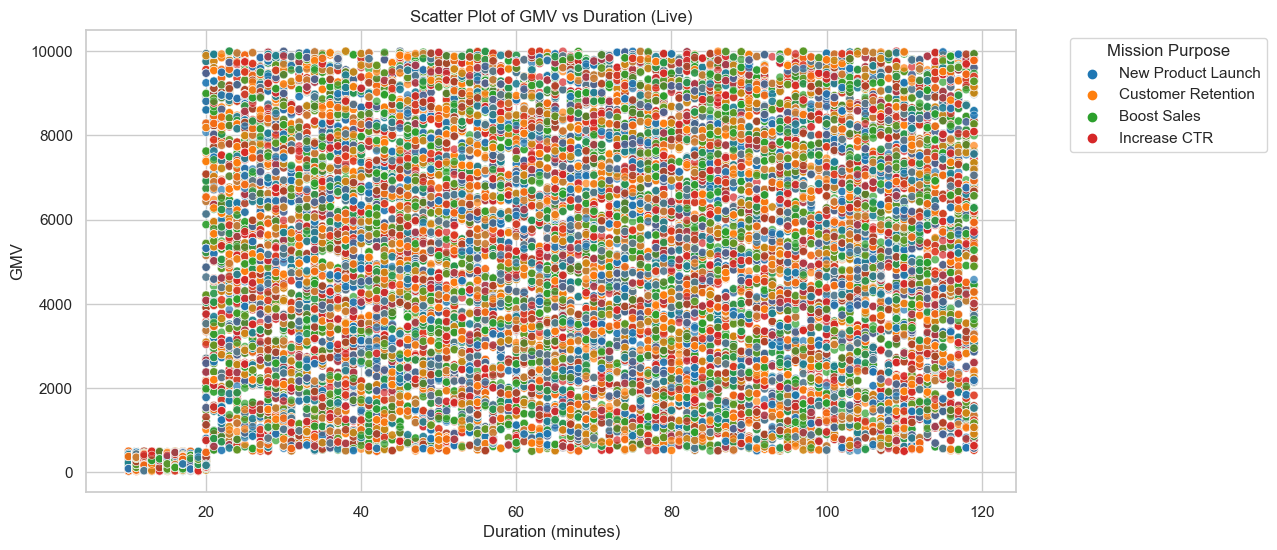

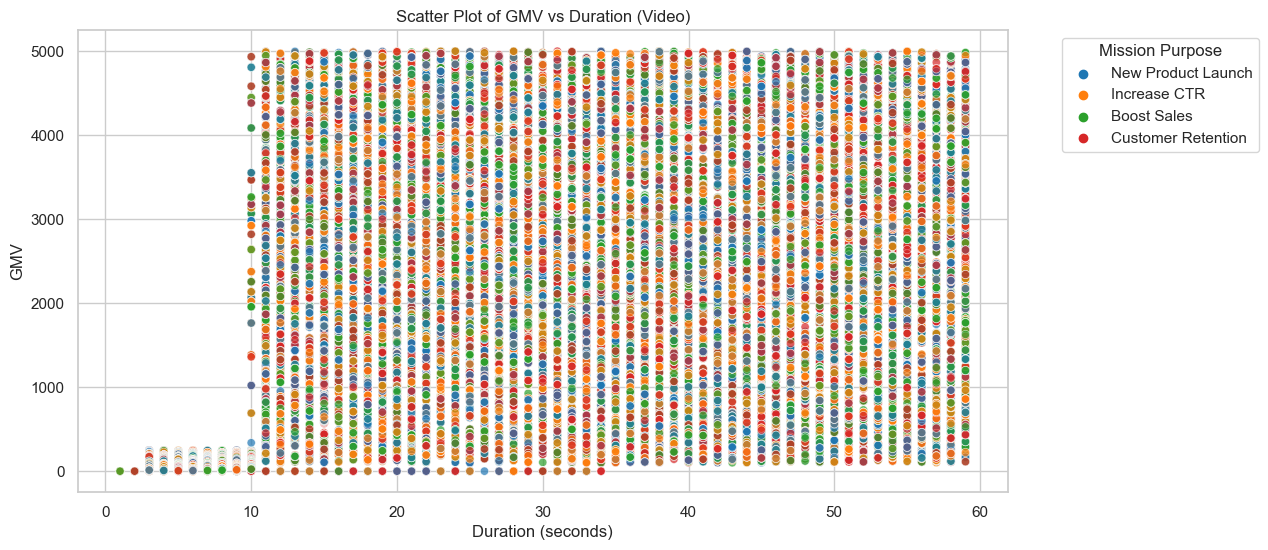

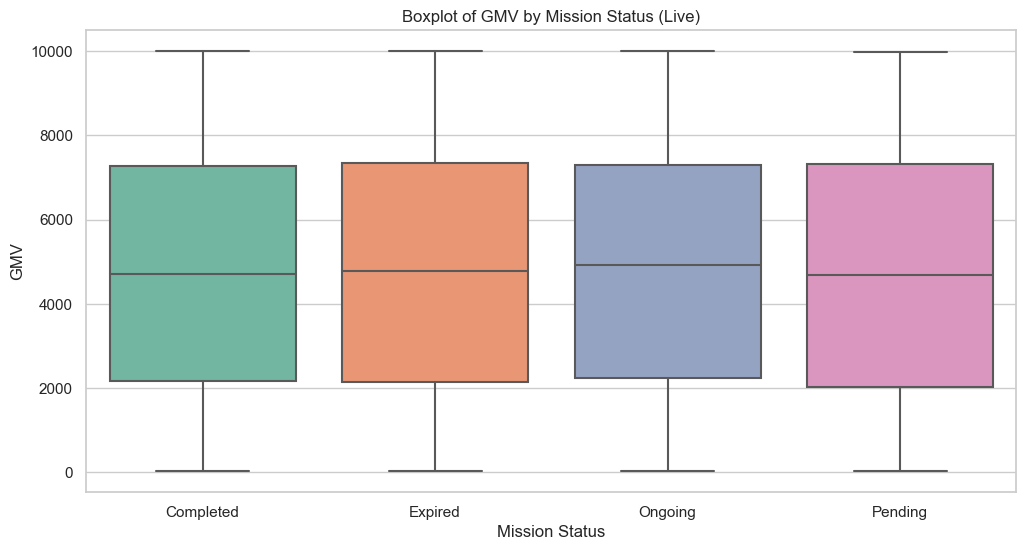

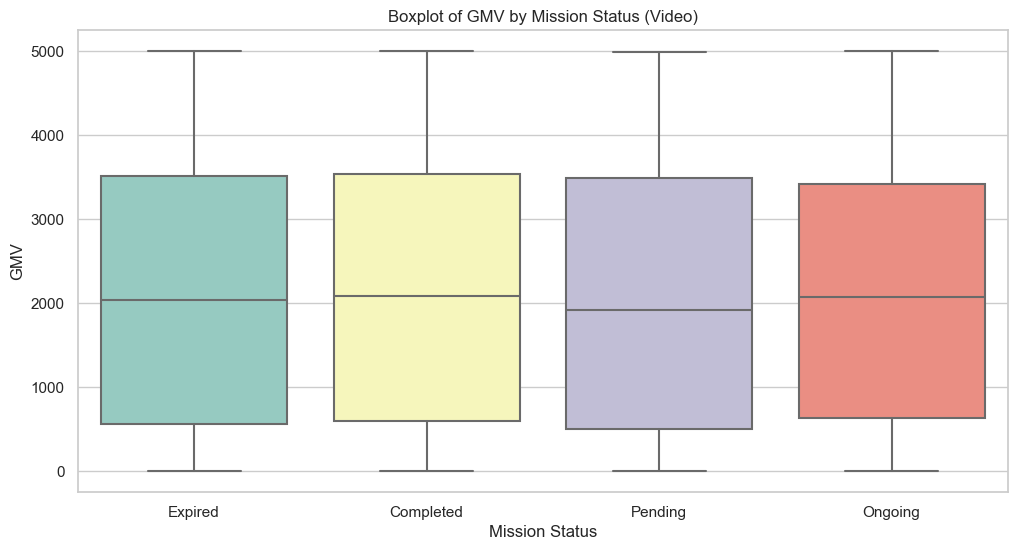

In [4]:
import seaborn as sns

import matplotlib.pyplot as plt

# Set seaborn style
sns.set(style="whitegrid")

# 1. Distribution of GMV for Live and Video
plt.figure(figsize=(12, 6))
sns.histplot(video_merged['Video GMV'], bins=50, color='blue', kde=True, label='Video GMV')
sns.histplot(live_merged['Lives GMV'], bins=50, color='orange', kde=True, label='Live GMV')
plt.title('Distribution of GMV for Video and Live Channels')
plt.xlabel('GMV')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# 2. Average GMV by Mission Purpose for Live Data
plt.figure(figsize=(12, 6))
avg_gmv_live = live_merged.groupby('Mission_purpose')['Lives GMV'].mean().sort_values()
sns.barplot(x=avg_gmv_live.values, y=avg_gmv_live.index, palette='viridis')
plt.title('Average GMV by Mission Purpose (Live)')
plt.xlabel('Average GMV')
plt.ylabel('Mission Purpose')
plt.show()

# 3. Average GMV by Mission Purpose for Video Data
plt.figure(figsize=(12, 6))
avg_gmv_video = video_merged.groupby('Mission_purpose')['Video GMV'].mean().sort_values()
sns.barplot(x=avg_gmv_video.values, y=avg_gmv_video.index, palette='coolwarm')
plt.title('Average GMV by Mission Purpose (Video)')
plt.xlabel('Average GMV')
plt.ylabel('Mission Purpose')
plt.show()

# 4. Scatter plot of GMV vs Duration for Live Data
plt.figure(figsize=(12, 6))
sns.scatterplot(data=live_merged, x='Duration_lives (minutes)', y='Lives GMV', hue='Mission_purpose', palette='tab10', alpha=0.7)
plt.title('Scatter Plot of GMV vs Duration (Live)')
plt.xlabel('Duration (minutes)')
plt.ylabel('GMV')
plt.legend(title='Mission Purpose', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# 5. Scatter plot of GMV vs Duration for Video Data
plt.figure(figsize=(12, 6))
sns.scatterplot(data=video_merged, x='Duration_video (seconds)', y='Video GMV', hue='Mission_purpose', palette='tab10', alpha=0.7)
plt.title('Scatter Plot of GMV vs Duration (Video)')
plt.xlabel('Duration (seconds)')
plt.ylabel('GMV')
plt.legend(title='Mission Purpose', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# 6. Boxplot of GMV by Mission Status for Live Data
plt.figure(figsize=(12, 6))
sns.boxplot(data=live_merged, x='Mission_status', y='Lives GMV', palette='Set2')
plt.title('Boxplot of GMV by Mission Status (Live)')
plt.xlabel('Mission Status')
plt.ylabel('GMV')
plt.show()

# 7. Boxplot of GMV by Mission Status for Video Data
plt.figure(figsize=(12, 6))
sns.boxplot(data=video_merged, x='Mission_status', y='Video GMV', palette='Set3')
plt.title('Boxplot of GMV by Mission Status (Video)')
plt.xlabel('Mission Status')
plt.ylabel('GMV')
plt.show()

### 一、主要原因分析
#### （一）渠道差异角度
1. **视频渠道** 
    - **互动性不足与用户停留时间短**：视频平均时长仅30秒，远低于直播的64分钟，用户难以在短时间内完整接收产品信息，缺乏深度互动（如实时答疑、限时优惠），导致转化效率低。
    - **内容吸引力分化**：视频GMV标准差为1587.32，波动较大，说明部分视频内容（如纯展示类）难以激发用户购买欲望，而促销类内容（如“Boost Sales”）表现较好，非促销类内容转化能力较弱。
2. **直播渠道** 
    - **效果不稳定**：直播GMV标准差高达2990.98，部分直播因时长过短（低于25分位数37分钟）、主播表现力不足或促销力度不够，导致流量转化不达标。
    - **用户疲劳与流量分散**：直播场次多但质量参差不齐，用户可能因频繁同类活动产生疲劳，或流向其他高热度直播间。

#### （二）活动目的角度
1. **Customer Retention（客户留存）** 
    - **依赖老客复购，新客增量少**：活动侧重维护现有用户，缺乏吸引新客的策略（如新客专属福利），GMV增长受限于老客消费频次和客单价上限。
    - **内容缺乏新鲜感**：留存活动多为常规福利（如积分兑换），缺乏创新形式（如定制化服务、老客专属直播），用户参与积极性下降。
2. **Increase CTR（提升点击率）** 
    - **点击-转化链路断层**：活动仅优化前端曝光（如标题、封面），但落地页加载慢、商品详情模糊或购买流程复杂，导致用户点击后流失，转化率（下单量/点击量）低。
    - **流量质量差**：可能通过低价引流吸引非目标用户，点击高但实际购买意愿低，浪费流量资源。
3. **New Product Launch（新品发布）** 
    - **新品认知度不足**：推广内容侧重产品参数罗列，缺乏使用场景演示、用户评价或KOL背书，用户对新品信任度低，决策周期长。
    - **预热不足**：新品活动前宣传期短，未通过多渠道（如预告视频、社群预热）积累期待感，直播或视频上线后流量爆发力弱。

#### （三）商家表现角度
1. **内容策划能力薄弱** 
    - 低GMV商家的视频多为简单产品展示，缺乏故事化、场景化内容（如“如何解决用户痛点”）；直播中主播话术生硬，互动环节少，无法有效引导下单。
2. **促销策略单一** 
    - 依赖平台通用折扣（如满减），缺乏差异化优惠（如阶梯折扣、组合套餐），难以刺激用户冲动消费。部分商家促销信息不突出，用户感知不到性价比。
3. **流量运营不足** 
    - 未合理利用平台流量工具（如付费推广、直播推荐位），仅依赖自然流量，导致曝光量低；活动期间未及时跟进用户反馈，错过优化时机。

#### （四）活动状态角度
1. **Pending（待处理）活动** 
    - **未启动预热**：活动状态为Pending时，商家可能未提前宣传，导致活动上线后冷启动困难，初期流量匮乏，影响GMV积累。
2. **Ongoing（进行中）活动** 
    - **周期过长导致疲劳**：部分进行中活动持续时间超过用户注意力周期，内容重复度高，用户参与度随时间下降，后期转化效率降低。
3. **Expired（已过期）活动** 
    - **未及时复盘优化**：活动结束后未分析数据（如用户流失节点、热门商品），导致同类活动重复问题，无法迭代改进。

### 二、改进措施
#### （一）渠道针对性优化
1. **视频渠道** 
    - **强化内容吸引力**：增加剧情化短视频，通过场景化故事展示产品价值（如“使用前后对比”）；在视频描述和评论区突出限时优惠、限时链接，缩短用户决策路径。
    - **互动引导转化**：设置“点击购物车”“立即领取优惠”等行动按钮，结合评论区实时答疑，提升转化效率；针对高GMV的“Boost Sales”类视频，复制成功模板（如强促销话术、快节奏剪辑）。
2. **直播渠道** 
    - **优化直播时长与结构**：参考75分位数时长（92分钟），避免过短（<30分钟）导致信息展示不完整；分段设计直播流程（如前30分钟产品讲解，中间40分钟互动抽奖，最后20分钟限时秒杀），保持用户注意力。
    - **提升互动与实时转化**：增加实时抽奖、限量抢购、弹幕投票等环节，利用主播话术强调“限时专属优惠”；结合数据实时调整直播节奏（如某商品点击高但下单低时，追加额外折扣）。

#### （二）活动目的精准策略
1. **Customer Retention（客户留存）** 
    - **分层运营老客**：根据用户历史消费数据，推送个性化优惠（如高价值客户专属折扣、积分翻倍活动）；直播中开设“老客回馈专场”，提供专属福利（如老客优先购买权）。
    - **结合情感营销**：通过视频分享老用户故事、使用体验，增强品牌粘性；推出“老带新”奖励机制，鼓励老客推荐新用户，扩大客群基础。
2. **Increase CTR（提升点击率）** 
    - **优化转化链路**：确保落地页加载速度<3秒，商品详情突出核心卖点和促销信息；设置“点击即领券”“一键加购”等功能，减少用户操作步骤。
    - **精准流量投放**：通过用户画像定向投放（如兴趣标签、历史浏览行为），吸引高购买意愿用户；分析高点击低转化案例，针对性优化落地页内容（如价格对比、用户评价）。
3. **New Product Launch（新品发布）** 
    - **提前预热与教育**：活动前3-7天通过短视频、图文预告新品亮点，邀请KOL/KOC进行试用测评；直播中演示产品使用场景（如美妆直播现场试用），解答用户疑虑。
    - **限时首发福利**：设置新品首发折扣、前100名赠品、买赠组合等稀缺性优惠，刺激用户尝新；收集首批用户反馈，快速优化产品描述和营销策略。

#### （三）商家能力提升与资源支持
1. **培训与工具赋能** 
    - 开设“内容策划”“直播话术”“数据复盘”等培训课程，提供模板库（如高转化视频脚本、直播流程表）；开放数据分析工具，帮助商家实时监控GMV、下单量等指标，及时调整策略。
2. **资源倾斜与激励** 
    - 对低GMV商家提供流量扶持（如首页推荐位、搜索加权），降低推广成本；设置“活动效果达标奖励”（如GMV达标后返还部分平台佣金），提升商家积极性。
3. **标杆案例共享** 
    - 定期分享高GMV商家经验（如Seller_0863的直播促销策略、Seller_0649的视频剪辑技巧），组织商家交流沙龙，促进方法论复制。

#### （四）活动状态全流程管理
1. **Pending活动预热** 
    - 建立活动预审机制，要求商家在活动启动前3天提交预热方案（如预告视频、社群海报）；平台提前1-2天通过Push通知、短信提醒用户活动即将开始，积累期待流量。
2. **Ongoing活动动态优化** 
    - 实时监控活动数据（如每小时GMV、下单量），发现转化低于预期时，临时追加优惠（如限时加码折扣）或调整内容（如更换主播、增加互动环节）；设置活动中期复盘节点，快速迭代策略。
3. **Expired活动复盘与迭代** 
    - 活动结束后自动生成复盘报告，分析GMV未达标原因（如流量不足、转化环节问题）；建立活动效果评分体系，对优质活动模板标记推荐，避免重复低效活动。

### 总结
GMV下降是渠道特性、活动设计、商家能力等多因素共同作用的结果。需针对不同渠道优化内容形式（视频重场景，直播重互动），围绕活动目的制定差异化策略（新品重预热，留存重分层），同时通过培训和资源支持提升商家执行能力，最终实现全链路效率提升。

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 读取数据
video_df = pd.read_excel('./01_source/Case Study.xlsx', sheet_name='Video data')
live_df = pd.read_excel('./01_source/Case Study.xlsx', sheet_name='Live data')
incentive_df = pd.read_excel('./01_source/Case Study.xlsx', sheet_name='Incentive mission data')

# 合并数据
video_merged = pd.merge(video_df, incentive_df, on='Seller_code', how='left')
live_merged = pd.merge(live_df, incentive_df, on='Seller_code', how='left')

# 设置图片清晰度
plt.rcParams['figure.dpi'] = 300

# 1. 渠道与活动目的交叉分析（分组柱状图）
# 计算各活动目的在不同渠道的GMV均值
channel_purpose_gmv = pd.concat([
    video_merged.groupby('Mission_purpose')['Video GMV'].mean().reset_index(name='GMV').assign(Channel='Video'),
    live_merged.groupby('Mission_purpose')['Lives GMV'].mean().reset_index(name='GMV').assign(Channel='Live')
])

# 绘制分组柱状图
plt.figure(figsize=(10, 6))
sns.barplot(x='Mission_purpose', y='GMV', hue='Channel', data=channel_purpose_gmv)
plt.title('Average GMV by Mission Purpose and Channel')
plt.xlabel('Mission Purpose')
plt.ylabel('Average GMV')
plt.legend(title='Channel')
plt.show()

# 2. 商家GMV分布与TOP案例（气泡图）
# 合并视频和直播数据
merged_data = pd.merge(video_df[['Seller_code', 'Duration_video (seconds)', 'Video GMV']],
                       live_df[['Seller_code', 'Duration_lives (minutes)', 'Lives GMV']],
                       on='Seller_code', how='outer')

# 绘制气泡图
plt.figure(figsize=(10, 6))
plt.scatter(merged_data['Duration_video (seconds)'], merged_data['Duration_lives (minutes)'],
            s=merged_data['Lives GMV'] + merged_data['Video GMV'], alpha=0.5)
plt.title('Merchant GMV Distribution (Bubble Size Represents GMV)')
plt.xlabel('Video Duration (seconds)')
plt.ylabel('Live Duration (minutes)')
plt.show()

# 3. 活动状态与GMV关联（折线图 + 面积图）
# 假设数据有时间维度，这里简单按日期排序，实际使用中需要根据真实数据处理
video_merged['Date'] = pd.to_datetime(video_merged['Date'])
live_merged['Date'] = pd.to_datetime(live_merged['Date'])

# 按日期和活动状态分组计算GMV总和
video_status_gmv = video_merged.groupby(['Date', 'Mission_status'])['Video GMV'].sum().unstack()
live_status_gmv = live_merged.groupby(['Date', 'Mission_status'])['Lives GMV'].sum().unstack()

# 绘制折线图 + 面积图
fig, axes = plt.subplots(2, 1, figsize=(10, 12))
video_status_gmv.plot.area(ax=axes[0])
axes[0].set_title('Relationship between Video Channel Mission Status and GMV')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Total GMV')

live_status_gmv.plot.area(ax=axes[1])
axes[1].set_title('Relationship between Live Channel Mission Status and GMV')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Total GMV')

plt.tight_layout()
plt.show()